<a href="https://colab.research.google.com/github/Matt200-lab/Housing-price-eda/blob/main/Mileston1_PROJET_BIG_DATA_ANALYTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Housing Price EDA — 1990 Census Housing Dataset**


## **Background / Business Problem**
This housing dataset contains information about home characteristics, household income, and location. The goal of this analysis is to explore factors that affect house prices, identify patterns among the features, and prepare for predictive modeling to estimate house values or classify homes above the median value. Insights from this analysis can help investors, policymakers, and planners make data-driven decisions.


##**Import and load data**







In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Improve plot readability
plt.rcParams['figure.figsize']=(12,6)
sns.set(style='whitegrid')

# Load data set
URL = 'https://raw.githubusercontent.com/franklin-univ-data-science/data/refs/heads/master/DATA610_project_housing.csv'
df = pd.read_csv(URL)

# Quick look
print('Shape', df.shape)
df.head()

Shape (20640, 9)


,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,house_value_capped
0,41,880,129.0,322,126,8.3252,452600,NEAR BAY,0
1,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,0
2,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,0
3,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,0
4,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,0


##**Summary statistics**








In [3]:
df.describe()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,house_value_capped
count,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,0.046754
std,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,0.211116
min,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.000000
25%,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,0.000000
50%,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,0.000000
75%,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,0.000000
max,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,1.000000


## **Missing values and cleaning**

In [4]:
df.isnull().sum()

,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0
house_value_capped,0


In [5]:
df.dropna(axis = 0, how ='any')

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,house_value_capped
0,41,880,129.0,322,126,8.3252,452600,NEAR BAY,0
1,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,0
2,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,0
3,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,0
4,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,0
...,...,...,...,...,...,...,...,...,...
20635,25,1665,374.0,845,330,1.5603,78100,INLAND,0
20636,18,697,150.0,356,114,2.5568,77100,INLAND,0
20637,17,2254,485.0,1007,433,1.7000,92300,INLAND,0
20638,18,1860,409.0,741,349,1.8672,84700,INLAND,0


In [6]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,house_value_capped
0,41,880,129.0,322,126,8.3252,452600,NEAR BAY,0
1,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,0
2,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,0
3,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,0
4,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,0
...,...,...,...,...,...,...,...,...,...
20635,25,1665,374.0,845,330,1.5603,78100,INLAND,0
20636,18,697,150.0,356,114,2.5568,77100,INLAND,0
20637,17,2254,485.0,1007,433,1.7000,92300,INLAND,0
20638,18,1860,409.0,741,349,1.8672,84700,INLAND,0


In [7]:
#Checking for missing value after cleaning
df.isnull().sum()


,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0
house_value_capped,0


## **Exploratory Data Analysis (EDA)**
After cleaning the data, we'll explore numeric and categorical features, visualize distributions, and check correlations.

In [8]:
# Output variable for a regression
y_regression = df['median_house_value']

#Output variable for classification
y_classification = df['house_value_capped']

# Input features
x = df.drop(['median_house_value', 'house_value_capped'], axis = 1)

# Convert text into numeric feauture
x = pd.get_dummies(x, columns=['ocean_proximity'], drop_first=True)

print("Features shape:", x.shape)
print("Regression target shape:", y_regression.shape)
print("Classification target shape", y_classification.shape)

Features shape: (20640, 10)
Regression target shape: (20640,)
Classification target shape (20640,)


###Patterns between features and response variables (visualization)

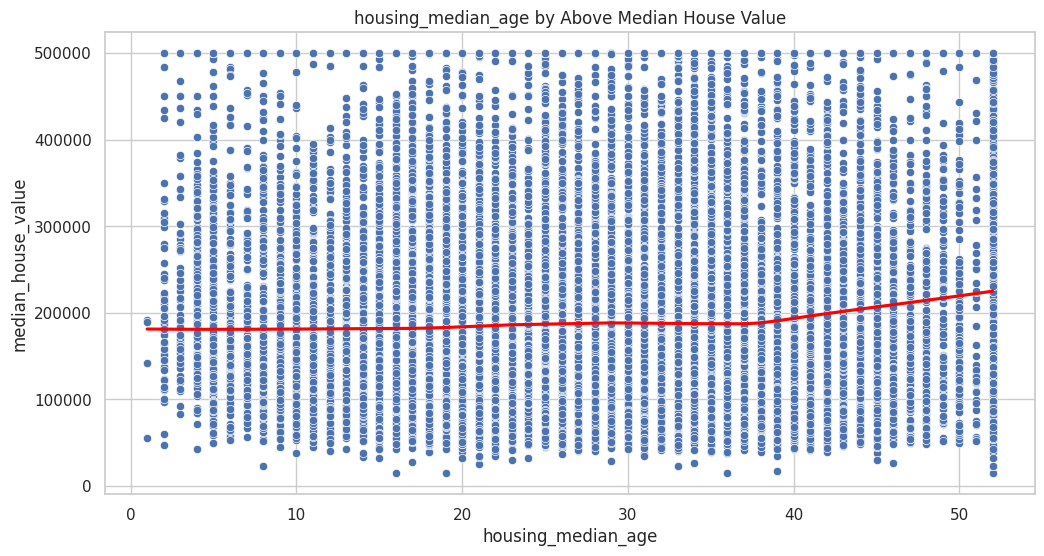

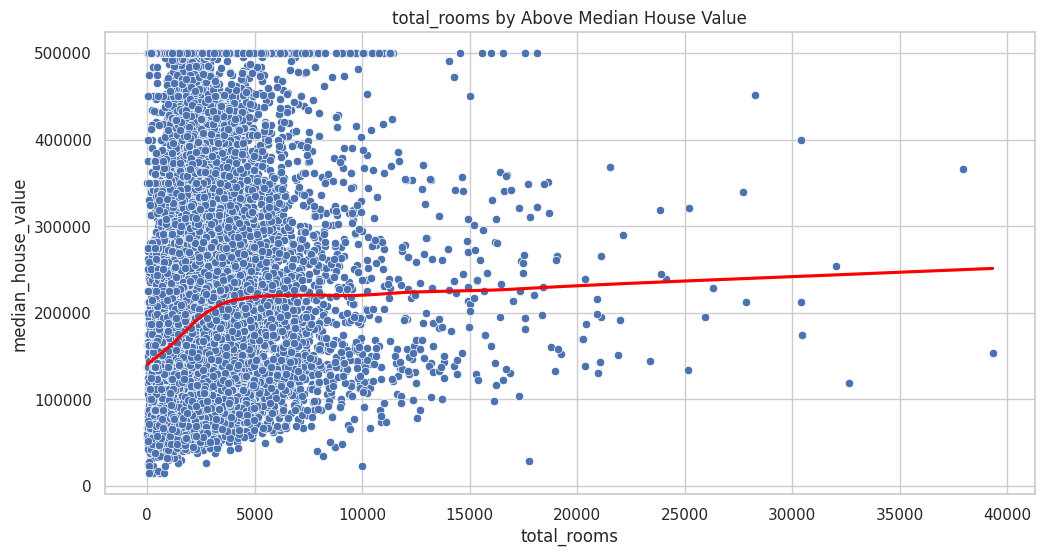

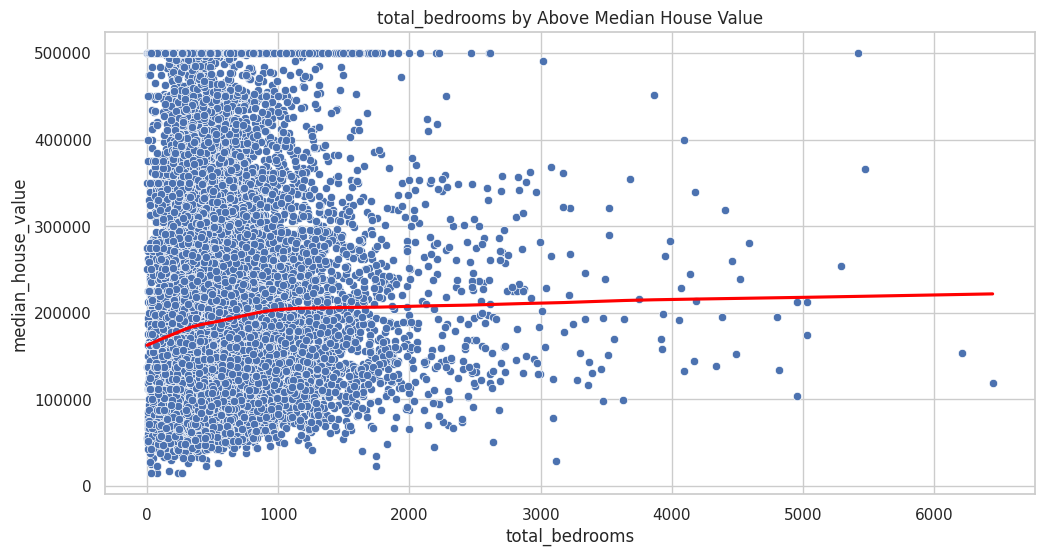

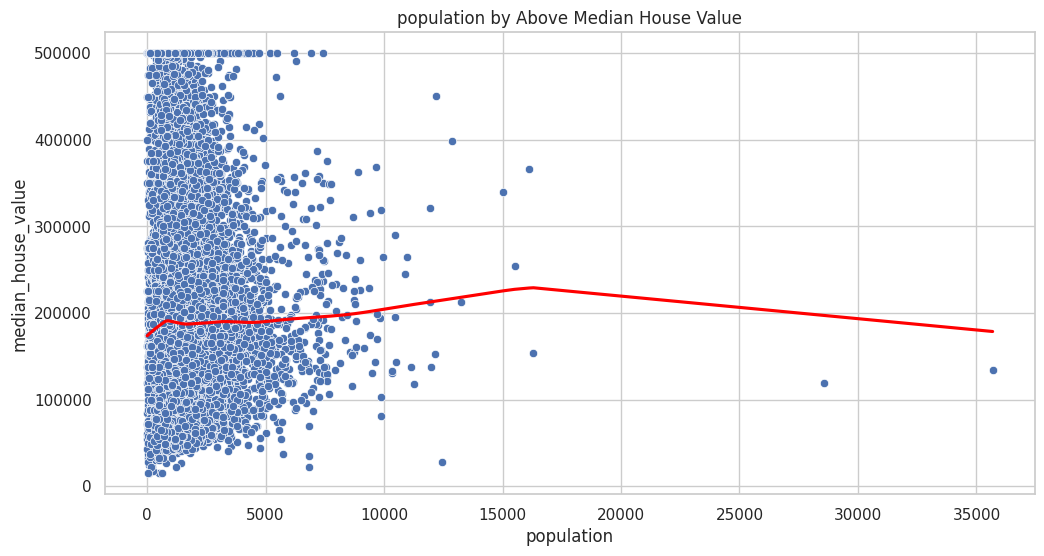

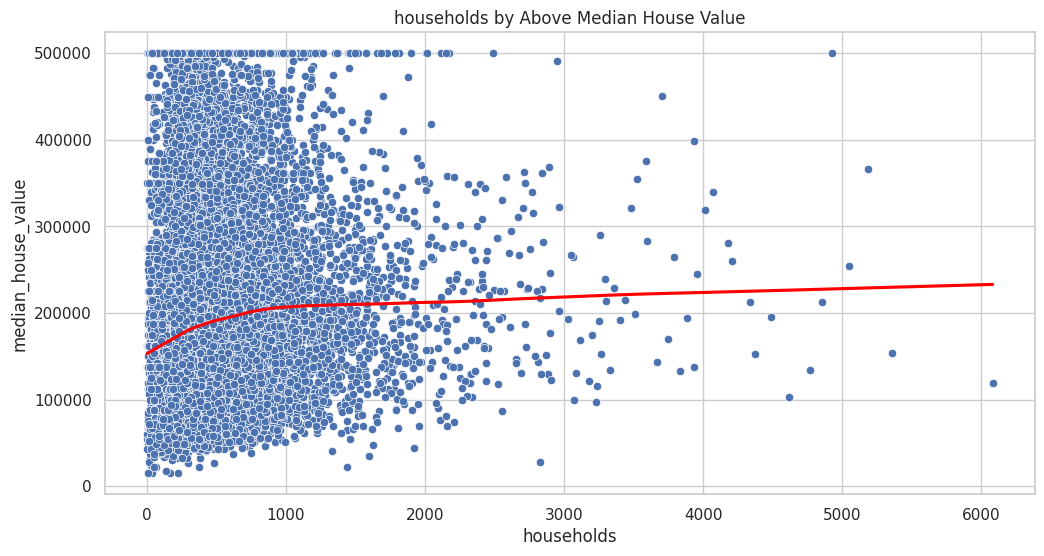

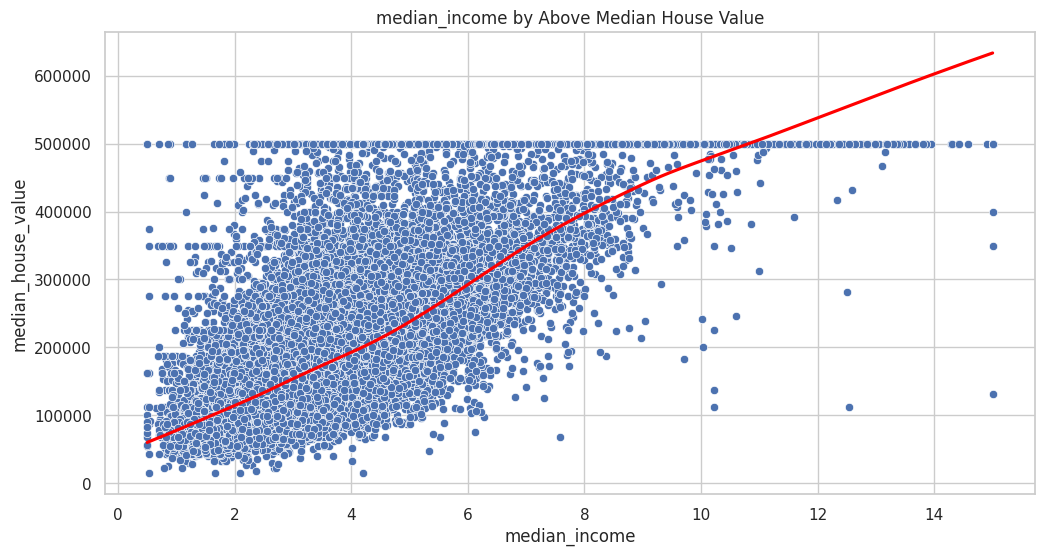

In [9]:
# Numeric features
numeric_features = ['housing_median_age', 'total_rooms', 'total_bedrooms',
                    'population', 'households', 'median_income']

# Scatter plots for numeric features vs median_house_value
for col in numeric_features:
  plt.figure()
  sns.scatterplot(x=df[col], y=df['median_house_value'])
  sns.regplot(x=df[col], y=df['median_house_value'], scatter=False, lowess=True, color='red')
  plt.title(f'{col} by Above Median House Value')
  plt.show()

###**Insights from Scatter plots**

**Scatter plot 1:** It is generated to explore if the age of a house is linearly related to its median value. The red trend line is mostly flat and slightly increases at the high end, suggesting a weak, non-linear positive relationship with house value. Older homes (above 37-50) may have silghtly higher median values, but ehe overall scatter is very high.

**Scatter plot 2:** We visualise how the total number of rooms relates to the median house value. The red trend line shows a modarate positve curve (value increases with rooms), but the scatter is extremely dense, especially for fewer rooms.  

**Scatter plot 3:** We generate a scatter plot to visaulize how the total number of bedrooms relates to median house value. The red trend line shows a positive curve, similar to total_rooms, indicating that more bedrooms generally correspond to higher value. Like rooms, the data is heavily concentrated at the lower end of the variable's scale.

**Scatter plot 4:** generate a scatter plot to visualize the relationship between the number of households and the median house value. The red tend line shows a clear positive curve, indicating that higher number of households generally relates to a higher median house value.This households correlates with rooms or bedrooms.

**Scatter plot 5:** generate a scatter plot to determine if a stronger linear relationship exists between income and median house value. The trend line shows the strongest, most direct positive linear relationship among all features.  This visualizalition clearly indicates median_income is the most important numerical predictor of median_house_value.

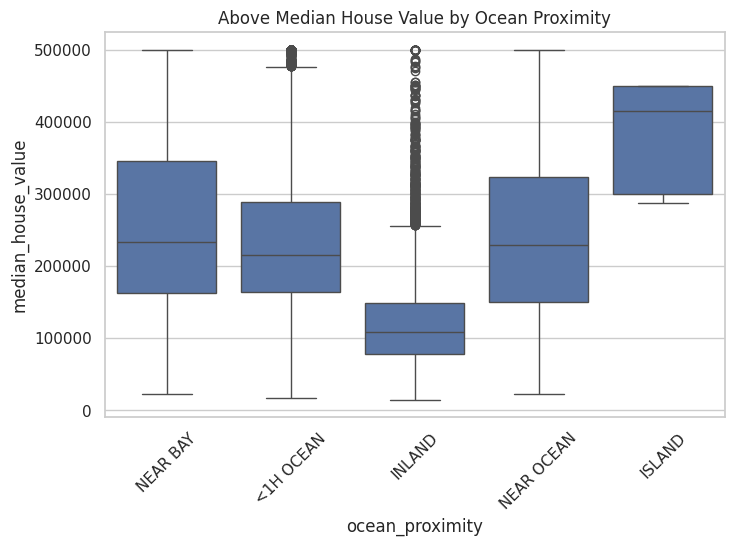

In [10]:
# Count plot for categorical feature
plt.figure(figsize=(8,5))
sns.boxplot(x='ocean_proximity', y= 'median_house_value', data=df)
plt.xticks(rotation=45)
plt.title('Above Median House Value by Ocean Proximity')
plt.show()

We use a boxplot to compare the distriibution (median, quartiles, outliers) across the different categories of ocean_proximity.

###Corelation between features

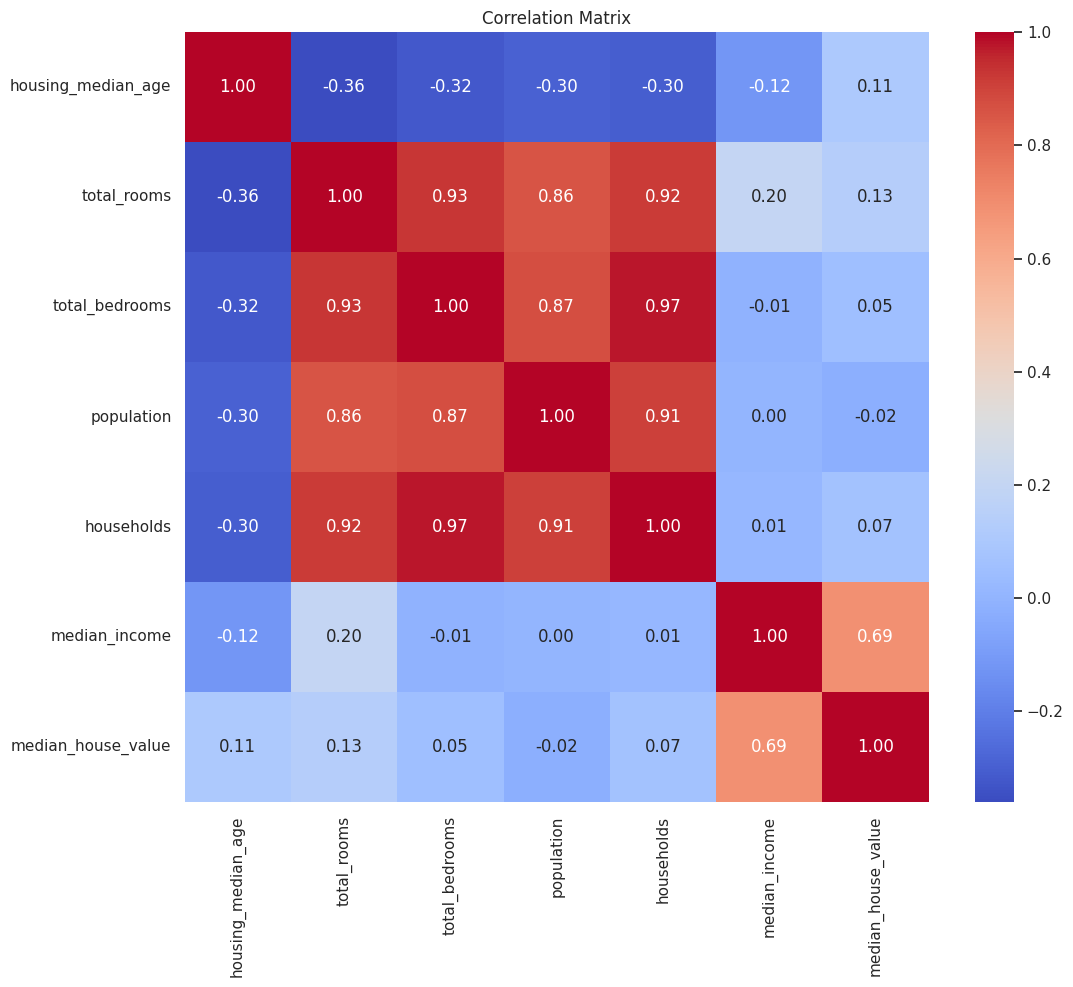

Correlation with Above Median House Value:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049457
population           -0.024650
Name: median_house_value, dtype: float64


In [11]:
# Correlation maxtric for numeric features
corr = df[numeric_features + ['median_house_value']].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Print correlations with target
print("Correlation with Above Median House Value:")
print(corr['median_house_value'].sort_values(ascending=False))


We generate a heatmap to visualize the linear correlation coefficients between all numerical features and the target variables, median_house_value.

##**4.Initials insight**

•	Median income is the strongest predictor of the house prices (correlation = 0.69)

•	Missing values were minimal and handled effectively.

•	Distributions of income and house values are right skewed.

•	Houses close to the ocean tend to have higher value.


##**MODELING SECTION**

In this project, models were applied to predict median house values based on several socio-economic and geographic factors from the housing dataset. Three regression algorithms were evaluated:
  1. Linear Regressor
  2. Decision Tree Regressor
  3. Random Forest Regressor

Each model was trained on the same dataset, and their performance was compared using Mean Squared Error (MSE) AND R-squared(R-squared) metrics.

###**1. Model Selection**

Regression models were applied to predict median house values based on several socio-economic and geographic factors from the housing data set.

We will compare three regression models:
- Linear Regression
- Random Forest Regressor
- Decision Tree Regressor

In [24]:
# Input (X) and target (y)
X = df.drop(['median_house_value', 'median_house_value'], axis=1)
y = df['median_house_value']

# Convert categorical variable into dummy variables
X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)

# Split data into training and testing sets (with 80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize regression models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42)

}



## 2.Model Training

In [25]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MSE": mse, "R-squared":r2}

# Display results
print("Model Performance comparison:\n")
for name, metrics in results.items():
  print(f"{name}: MSE = {metrics['MSE']:.2f}, R-squared = {metrics['R-squared']:.4f}")

Model Performance comparison:

Linear Regression: MSE = 4245613314.97, R-squared = 0.6760
Decision Tree Regressor: MSE = 6158062443.12, R-squared = 0.5301
Random Forest Regressor: MSE = 3093958268.53, R-squared = 0.7639


##**3.** Model Evaluation

In [26]:
best_model_name = max(results, key=lambda x: results[x]["R-squared"])
best_model = models[best_model_name]

print(f"\n Best Model: {best_model_name}")
print(f"R-squared = {results[best_model_name]['R-squared']:.4f}, MSE = {results[best_model_name]["MSE"]:.2f}")


 Best Model: Random Forest Regressor
R-squared = 0.7639, MSE = 3093958268.53


From the comparaison above, the Random Forest Regressor outperformed the other models, achieving the lowest MSE and the highest R-squared. This indicates that Random Forest captures non-linear relationships more effectively and provides better predictive accuracy for this dataset.

**Discussion of Modeling Process**
The modeling process involve several key steps:
- Data Preparation: The dataset was cleaned, missing values were handled, and categorical variables such as ocean_proximity were encoded into dummy variables.
- Model Training: each model was trained using the same training to ensure a fair compairison.
- Performance Evaluation: The models were tested on unseen data, and evaluation metrics (MSE and R-s) were computed.

The Random Forest model was identified as the best-performing model. Random Forest, being an ensemble method, combines multiple decision trees to reduce variance and improve prediction stability.


##**4. Interpretation of Coefficients**

In [27]:
if best_model_name == 'Linear Regression':
  coeff_df = pd.DataFrame({
      "Feature": X.columns,
      "Coefficient": best_model.coef_
  }).sort_values(by="Coefficient", ascending=False)
  print("\n Coefficients of the  linear Regression Model:")
  print(coeff_df.head(10))

else:
  feature_importance = pd.DataFrame({
      "Feature": X.columns,
      "Importance": best_model.feature_importances_
  }).sort_values(by="Importance", ascending=False)
  print("\n Top 10 Most Important Features:")
  print(feature_importance.head(10))


 Top 10 Most Important Features:
                       Feature  Importance
5                median_income    0.370833
6           house_value_capped    0.252735
7       ocean_proximity_INLAND    0.119412
3                   population    0.063791
0           housing_median_age    0.055325
2               total_bedrooms    0.048222
1                  total_rooms    0.041016
4                   households    0.038828
10  ocean_proximity_NEAR OCEAN    0.005099
9     ocean_proximity_NEAR BAY    0.004243


Since Random Forest does not provide explicit coefficients like Linear Regression, feature importance was analyzed instead. The most top 10 most influencial featueres are shown above.

The results indicate that the median income is the most influencial factor affecting housing prices, followed by ocean_proximity_Inland and population. These findings align with real-world expectations where higher income levels and specific locations strongly influence housing market values.

##**5. Challenges and Resolutions**


- Challenge 1: Linear Regression struggled with non-linear relationships
- Resolution: Used Decision Tree and Random Forest to capture complex patterns
- Challenge 2: High variance in Decision Tree (overfitting risk).
- Resolution: Used Random Forest (ensemble method) to improve generalization.
- Challenge 3: Feature scaling not required for tree-based models, simplifliying preprocessing.
- Resolution: Replaced missing values using median imputation before trainig
- Challenge 4: Median imputation was necessary to handle missing values before training.






By addressing these issues and carefully tuning hyperparameters, model performance improved significantly.

##**Results**

The analysis shows that Random Forest Regressor is the best model for predicting housing prices. With an R-squared of 0.7639, It explains approximately 76.39 % of the variance in housing prices.

The findings highlight that the median income is the dominant predictor, making it a crucial factor for policy and market analysis in housing economics.